Completed σ=1, window=10, PnL=$588.33
Completed σ=1, window=15, PnL=$732.61
Completed σ=1, window=20, PnL=$744.05
Completed σ=1, window=25, PnL=$802.90
Completed σ=1, window=30, PnL=$439.67
Completed σ=1, window=35, PnL=$987.03
Completed σ=1, window=40, PnL=$244.67
Completed σ=1, window=45, PnL=$954.04
Completed σ=1, window=50, PnL=$1153.87
Completed σ=1, window=55, PnL=$841.94
Completed σ=1, window=60, PnL=$624.98
Completed σ=1, window=65, PnL=$1007.10
Completed σ=1, window=70, PnL=$595.60
Completed σ=1, window=75, PnL=$918.97
Completed σ=1, window=80, PnL=$904.37
Completed σ=2, window=10, PnL=$926.42
Completed σ=2, window=15, PnL=$886.71
Completed σ=2, window=20, PnL=$1645.54
Completed σ=2, window=25, PnL=$1397.22
Completed σ=2, window=30, PnL=$1518.11
Completed σ=2, window=35, PnL=$424.35
Completed σ=2, window=40, PnL=$1795.93
Completed σ=2, window=45, PnL=$0.00
Completed σ=2, window=50, PnL=$0.00
Completed σ=2, window=55, PnL=$0.00
Completed σ=2, window=60, PnL=$0.00
Completed σ=2,

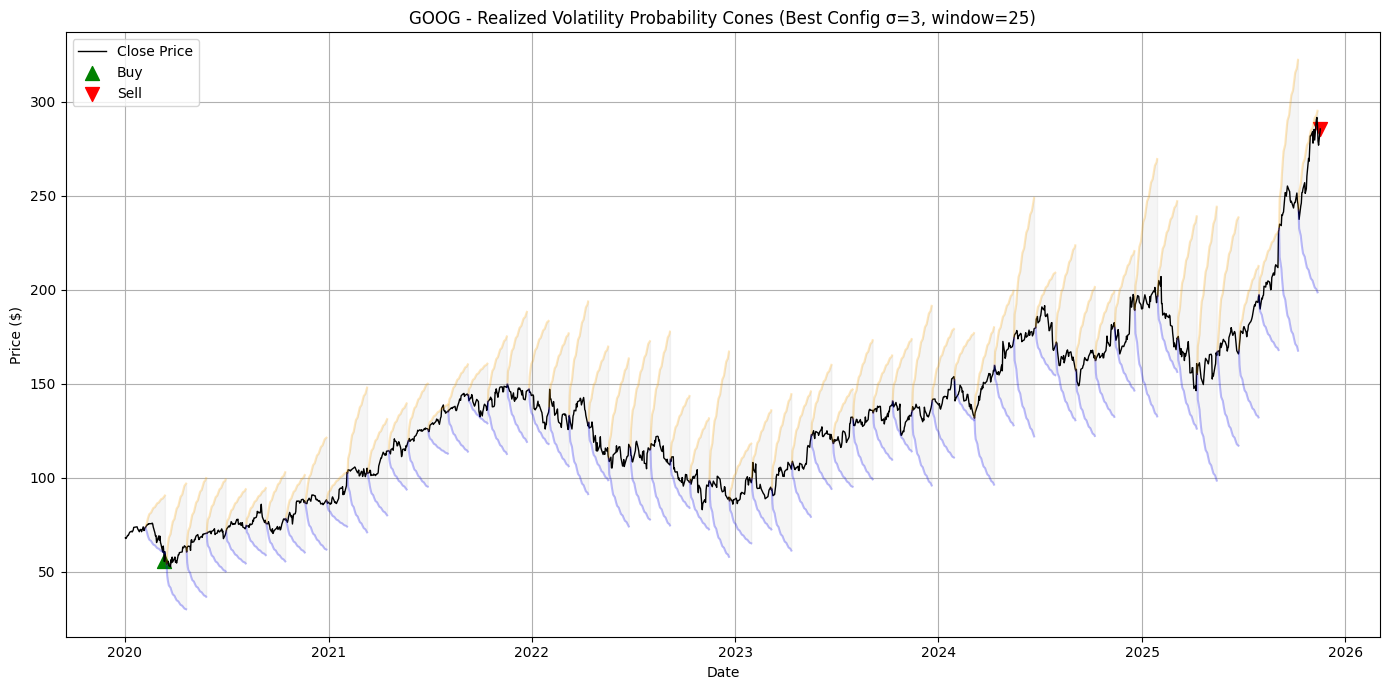

In [15]:
import yfinance as yf
from datetime import datetime
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import xlwings as xw

# ---------------- Parameters ----------------
ticker = "GOOG"
shares = 10
start_date = "2020-01-01"
end_date = datetime.today().strftime("%Y-%m-%d")

# ---------------- Fetch Data ----------------
stock = yf.Ticker(ticker)
hist = stock.history(start=start_date, end=end_date)
hist = hist[["Close"]].copy()
hist.dropna(inplace=True)
hist["Date"] = hist.index.date

# ---------------- Helper Function ----------------
def get_probability_bands(hist, ref_date, sigma_multiplier, window):
    current_price = hist.loc[hist["Date"] == ref_date, "Close"].values[0]

    t = window

    idx = hist.index.get_loc(hist.loc[hist["Date"] == ref_date].index[0])

    if idx < window:
        return np.nan, np.nan, np.nan, np.nan

    past_returns = hist["Close"].iloc[idx - window:idx].pct_change().dropna()
    sigma = np.std(past_returns) * math.sqrt(252)  # annualized vol

    upper = current_price * math.exp(sigma_multiplier * sigma * math.sqrt(t / 252))
    lower = current_price * math.exp(- sigma_multiplier * sigma * math.sqrt(t / 252))

    return current_price, lower, upper, sigma

# ---------------- Backtesting Loop ----------------
def run_backtest(hist, window, sigma_multiplier):
    positions = []
    cones = []
    in_trade = False
    entry_price = None

    dates = hist["Date"].tolist()
    i = 0

    while i < len(dates) - window:
        ref_date = dates[i]
        segment_dates = dates[i:min(i + window, len(dates))]

        current_price, lower_band, upper_band, sigma = get_probability_bands(hist, ref_date, sigma_multiplier, window)
        if np.isnan(lower_band):
            i += window
            continue

        cones.append({
            "ref_date": ref_date,
            "end_date": segment_dates[-1],
            "price": current_price,
            "lower": lower_band,
            "upper": upper_band,
            "sigma": sigma
        })

        for d in segment_dates:
            price = hist.loc[hist["Date"] == d, "Close"].values[0]

            # Entry condition
            if not in_trade and price < lower_band:
                in_trade = True
                entry_price = price
                entry_date = d
                positions.append({
                    "Type": "BUY",
                    "Date": d,
                    "Price": price,
                    "PNL": 0
                })

            # Exit condition
            elif in_trade and price >= upper_band:
                in_trade = False
                exit_price = price
                pnl = (exit_price - entry_price) * shares
                positions.append({
                    "Type": "SELL",
                    "Date": d,
                    "Price": price,
                    "PNL": pnl
                })
                entry_price, entry_date = None, None

        i += window

    if in_trade and entry_price:
        last_price = hist["Close"].iloc[-1]
        pnl = (last_price - entry_price) * shares
        positions.append({
            "Type": "SELL (forced)",
            "Date": hist["Date"].iloc[-1],
            "Price": last_price,
            "PNL": pnl
        })

    # ---------------- Results ----------------
    trades = pd.DataFrame(positions)
    total_pnl = trades["PNL"].sum() if not trades.empty else 0
    num_trades = len(trades) // 2 if not trades.empty else 0

    return trades, total_pnl, num_trades, cones

results = []
best_config = None
max_pnl = -np.inf

window_range = range(10, 85, 5)

for sigma_mult in [1, 2, 3]:
    for w in window_range:
        trades, total_pnl, num_trades, cones = run_backtest(hist, w, sigma_mult)
        results.append({
            "Sigma_Multiplier": sigma_mult,
            "Window": w,
            "Final_PnL": total_pnl,
            "Num_Trades": num_trades
        })

        if total_pnl > max_pnl:
            max_pnl = total_pnl
            best_config = (sigma_mult, w, trades, cones, total_pnl, num_trades)

        print(f"Completed σ={sigma_mult}, window={w}, PnL=${total_pnl:.2f}")

# ---------------- Results ----------------
results_df = pd.DataFrame(results)
best_sigma, best_window, best_trades, best_cones, best_total_pnl, best_num_trades = best_config


# print("\n===== OPTIMIZATION RESULTS =====")
# print(results_df.sort_values("Final_PnL", ascending=False).head(10))

print("\n===== BEST CONFIGURATION =====")
print(f"Sigma Multiplier: {best_sigma}")
print(f"Window: {best_window}")
print(f"Total PnL: ${best_total_pnl:,.2f}")
print(f"Number of Completed Trades: {best_num_trades}")

print("\n===== INDIVIDUAL TRADES (Best Config) =====")
for _, trade in best_trades.iterrows():
    if "SELL" in trade["Type"]:
        print(f"{trade['Type']:12} | Date: {trade['Date']} | Price: ${trade['Price']:.2f} | "
              f"PNL: ${trade['PNL']:.2f}")
    else:
        print(f"{trade['Type']:12} | Date: {trade['Date']} | Price: ${trade['Price']:.2f}")

# ---------------- Visualization ----------------
plt.figure(figsize=(14,7))
plt.plot(hist["Date"], hist["Close"], label="Close Price", color="black", linewidth=1)

for cone in best_cones:
    start = datetime.strptime(str(cone["ref_date"]), "%Y-%m-%d")
    end = datetime.strptime(str(cone["end_date"]), "%Y-%m-%d")
    t_range = pd.date_range(start, end, freq="B")
    n = len(t_range)

    days = np.arange(n)
    sigma_curve = np.sqrt(days / 252)

    # Smooth probability curves (like your original curved version)
    upper_curve = cone["price"] * np.exp((math.log(cone["upper"]/cone["price"])) * sigma_curve / sigma_curve[-1])
    lower_curve = cone["price"] * np.exp((math.log(cone["lower"]/cone["price"])) * sigma_curve / sigma_curve[-1])

    plt.fill_between(t_range, lower_curve, upper_curve, color="gray", alpha=0.08)
    plt.plot(t_range, upper_curve, color="orange", alpha=0.25)
    plt.plot(t_range, lower_curve, color="blue", alpha=0.25)

buy_points = best_trades[best_trades["Type"] == "BUY"]
sell_points = best_trades[best_trades["Type"].str.contains("SELL")]

plt.scatter(buy_points["Date"], buy_points["Price"], color="green", label="Buy", marker="^", s=100)
plt.scatter(sell_points["Date"], sell_points["Price"], color="red", label="Sell", marker="v", s=100)

plt.title(f"{ticker} - Realized Volatility Probability Cones (Best Config σ={best_sigma}, window={best_window})")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


------ CURRENT IMPLIED VOLATILITY CONE ------

------ CURRENT IMPLIED VOLATILITY CONE ------
Expiration  Days  IV (annualized)  Lower Bound 1σ ($)  Lower Bound 2σ ($)  Lower Bound 3σ ($)  Upper Bound 1σ ($)  Upper Bound 2σ ($)  Upper Bound 3σ ($)
2025-11-21     2             1.56              285.20              284.81              284.41              286.00              286.40              286.80
2025-11-28     9             0.78              285.18              284.76              284.34              286.02              286.45              286.87
2025-12-05    16             0.78              285.04              284.48              283.92              286.16              286.73              287.29
2025-12-12    23             0.78              284.93              284.25              283.58              286.28              286.95              287.63
2025-12-19    30             0.78              284.83              284.06              283.30              286.37              287.15   

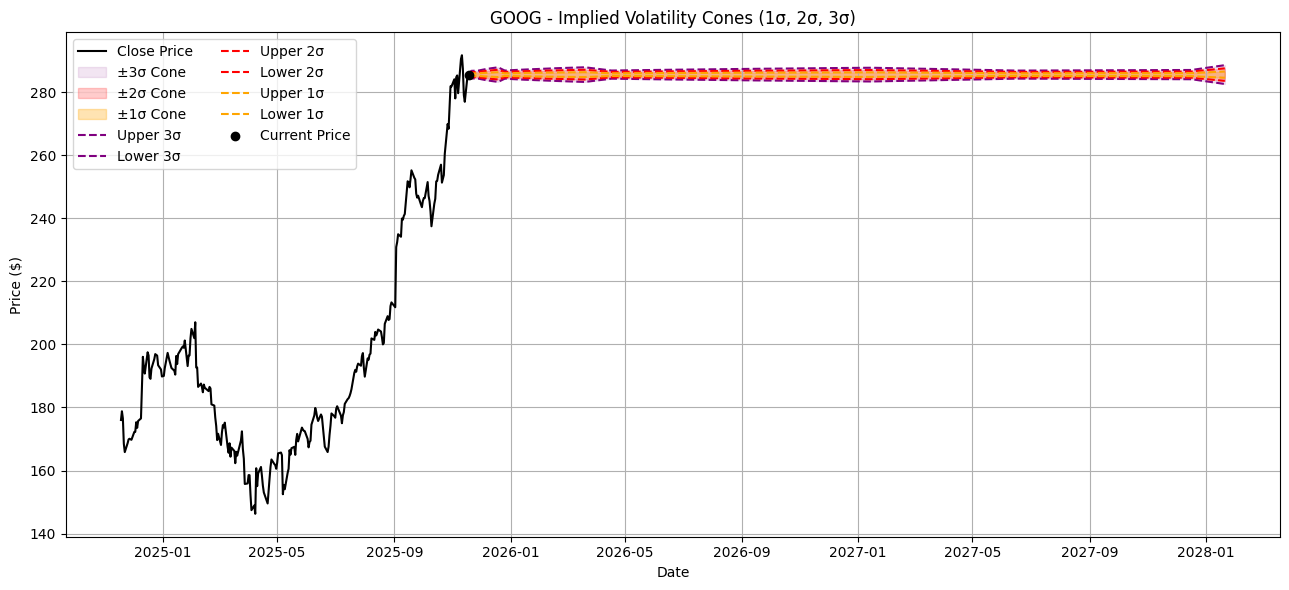

In [16]:
import yfinance as yf
from datetime import datetime, timedelta
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ticker = "GOOG"
shares = 10
start_date = "2020-01-01"
end_date = datetime.today().strftime("%Y-%m-%d")

print("\n------ CURRENT IMPLIED VOLATILITY CONE ------")
end_date = datetime.today().strftime("%Y-%m-%d")
start_date = (datetime.today() - timedelta(days=365)).strftime("%Y-%m-%d")

# ---------------- Fetch Data ----------------
stock = yf.Ticker(ticker)
hist = stock.history(start=start_date, end=end_date)
hist = hist[["Close"]].copy()
hist.dropna(inplace=True)
hist["Date"] = hist.index.date

# ---------------- Current Probability Cones (Using Implied Vol) ----------------
print("\n------ CURRENT IMPLIED VOLATILITY CONE ------")

current_price = hist["Close"].iloc[-1]
today = datetime.today()

expirations = stock.options
cone_table = []

for exp in expirations:
    opt_chain = stock.option_chain(exp)
    calls, puts = opt_chain.calls, opt_chain.puts

    atm_strike = calls.iloc[(calls["strike"] - current_price).abs().argmin()]["strike"]
    try:
        atm_call_iv = calls.loc[calls["strike"] == atm_strike, "impliedVolatility"].values[0]
        atm_put_iv = puts.loc[puts["strike"] == atm_strike, "impliedVolatility"].values[0]
    except IndexError:
        continue

    sigma = (atm_call_iv + atm_put_iv) / 2
    exp_date = datetime.strptime(exp, "%Y-%m-%d")
    t = (exp_date - today).days

    if t<= 0:
        continue
    #68%
    upper_1 = current_price * math.exp(sigma * math.sqrt(t / 252))
    lower_1 = current_price * math.exp(-sigma * math.sqrt(t / 252))
    #95%
    upper_2 = current_price * math.exp(2*sigma * math.sqrt(t / 252))
    lower_2 = current_price * math.exp(-2*sigma * math.sqrt(t / 252))
    #99%
    upper_3 = current_price * math.exp(3*sigma * math.sqrt(t / 252))
    lower_3 = current_price * math.exp(-3*sigma * math.sqrt(t / 252))

    cone_table.append({
        "Expiration": exp_date,
        "Days": t,
        "IV (annualized)": round(sigma * 100, 2),

        "Lower Bound 1σ ($)": round(lower_1, 2),
        "Lower Bound 2σ ($)": round(lower_2, 2),
        "Lower Bound 3σ ($)": round(lower_3, 2),

        "Upper Bound 1σ ($)": round(upper_1, 2),
        "Upper Bound 2σ ($)": round(upper_2, 2),
        "Upper Bound 3σ ($)": round(upper_3, 2),
    })

cone_df = pd.DataFrame(cone_table)
print(cone_df.to_string(index=False))

# ---------------- Plot Current Probability Cones ----------------
plt.figure(figsize=(13,6))
plt.plot(hist["Date"], hist["Close"], label="Close Price", color="black")

if len(cone_df) > 0:
    # Sort by expiration date
    cone_df = cone_df.sort_values("Expiration")

    future_dates = [today] + cone_df["Expiration"].tolist()

    # Create each cone (1σ, 2σ, 3σ)
    lowers_1 = [current_price] + cone_df["Lower Bound 1σ ($)"].tolist()
    uppers_1 = [current_price] + cone_df["Upper Bound 1σ ($)"].tolist()

    lowers_2 = [current_price] + cone_df["Lower Bound 2σ ($)"].tolist()
    uppers_2 = [current_price] + cone_df["Upper Bound 2σ ($)"].tolist()

    lowers_3 = [current_price] + cone_df["Lower Bound 3σ ($)"].tolist()
    uppers_3 = [current_price] + cone_df["Upper Bound 3σ ($)"].tolist()

    # Fill the 1σ, 2σ, and 3σ cones with progressively lighter colors
    plt.fill_between(future_dates, lowers_3, uppers_3, color="purple", alpha=0.1, label="±3σ Cone")
    plt.fill_between(future_dates, lowers_2, uppers_2, color="red", alpha=0.2, label="±2σ Cone")
    plt.fill_between(future_dates, lowers_1, uppers_1, color="orange", alpha=0.3, label="±1σ Cone")

    # Optional: outline lines for visual clarity
    plt.plot(future_dates, uppers_3, color="purple", linestyle="--", label="Upper 3σ")
    plt.plot(future_dates, lowers_3, color="purple", linestyle="--", label="Lower 3σ")

    plt.plot(future_dates, uppers_2, color="red", linestyle="--", label="Upper 2σ")
    plt.plot(future_dates, lowers_2, color="red", linestyle="--", label="Lower 2σ")

    plt.plot(future_dates, uppers_1, color="orange", linestyle="--", label="Upper 1σ")
    plt.plot(future_dates, lowers_1, color="orange", linestyle="--", label="Lower 1σ")

    plt.scatter(today, current_price, color="black", zorder=5, label="Current Price")

plt.title(f"{ticker} - Implied Volatility Cones (1σ, 2σ, 3σ)")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend(loc="upper left", ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()